<!-- @format -->

# 01 - Data Understanding

Notebook này dành cho khám phá dữ liệu ban đầu và trực quan hóa cơ bản.


<!-- @format -->

## Checklist

- Đọc file Data_Train.xlsx
- Kiểm tra kích thước, kiểu dữ liệu, missing values, duplicate
- Khảo sát phân phối Price
- Phân tích giá theo Airline, Source, Destination, Total_Stops
- Ghi nhận insight để dùng cho feature engineering


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [9]:

df = pd.read_excel("../data/raw/Data_Train.xlsx")
display(df.head())


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [10]:
# TODO: kiểm tra shape, info, describe, missing values, duplicate
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

Shape: (10683, 11)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB
None


In [11]:
print("\nDescribe:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Describe:
              Price
count  10683.000000
mean    9087.064121
std     4611.359167
min     1759.000000
25%     5277.000000
50%     8372.000000
75%    12373.000000
max    79512.000000

Missing values:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Duplicate rows: 220


In [12]:
display(df[['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info']].nunique().to_frame('unique_values'))
display(df['Total_Stops'].value_counts(dropna=False).to_frame('count'))

,unique_values
Airline,12
Source,5
Destination,6
Total_Stops,5
Additional_Info,10


,count
Total_Stops,
1 stop,5625
non-stop,3491
2 stops,1520
3 stops,45
NaN,1
4 stops,1


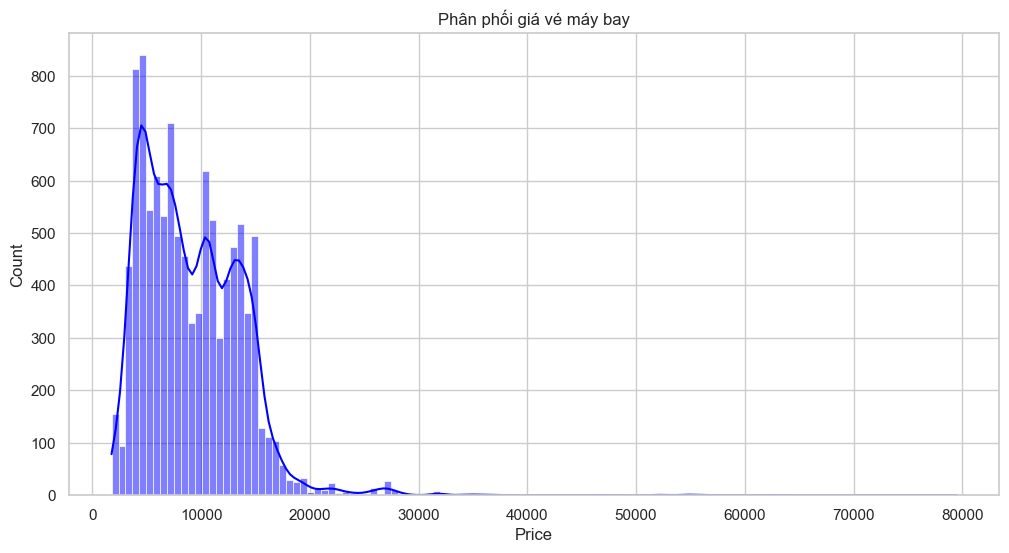

In [13]:
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Phân phối giá vé máy bay')
plt.show()

<!-- @format -->

### Biểu đồ Histogram về phân phối giá vé máy bay:

- Dữ liệu bị lệch phải rất rõ rệt. Đa số giá vé tập trung ở phân khúc thấp và trung bình (khoảng dưới 15.000).

- Phần lớn khách hàng lựa chọn các chuyến bay giá rẻ. Tuy nhiên, có một khoảng dài kéo về phía bên phải (lên đến 80.000). Điều này chứng tỏ sự hiện diện của các giá trị ngoại lai hoặc các hạng vé cao cấp.


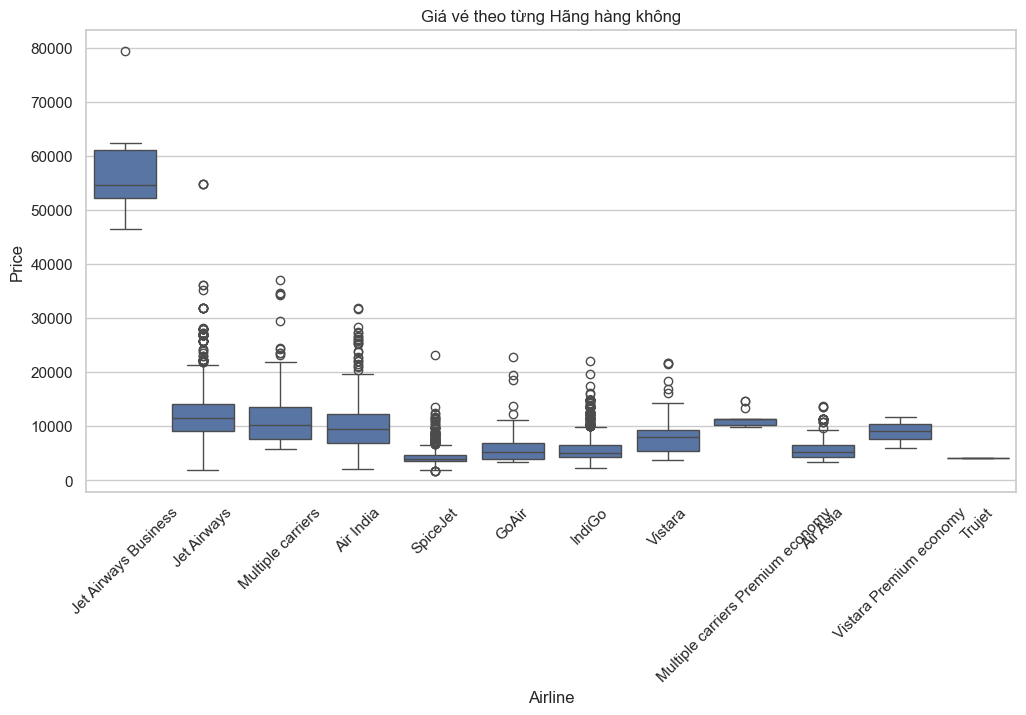

In [9]:
sns.boxplot(y='Price', x='Airline', data=df.sort_values('Price', ascending=False))
plt.xticks(rotation=45)
plt.title('Giá vé theo từng Hãng hàng không')
plt.show()

<!-- @format -->

### Biểu đồ Boxplot theo Hãng cho thấy sự phân hóa thương hiệu:

- Jet Airways Business có mức giá cao đột biến và tách biệt hoàn toàn so với phần còn lại (đường Median cao nhất). Đây là nhóm khách hàng hạng thương gia.

- Các hãng như Jet Airways và Multiple Carriers có "hộp" khá dài và nhiều điểm outliers phía trên. Điều này cho thấy chiến lược giá của họ rất linh hoạt, thay đổi mạnh tùy vào thời điểm hoặc chặng bay.

- Hãng giá rẻ: IndiGo, SpiceJet, GoAir, và Air Asia có mức giá trung bình thấp và ổn định hơn (hộp ngắn và nằm ở vùng thấp).

- Từ đó ta thấy được tên hãng hàng không là một đặc trưng cực kỳ quan trọng để dự báo giá.


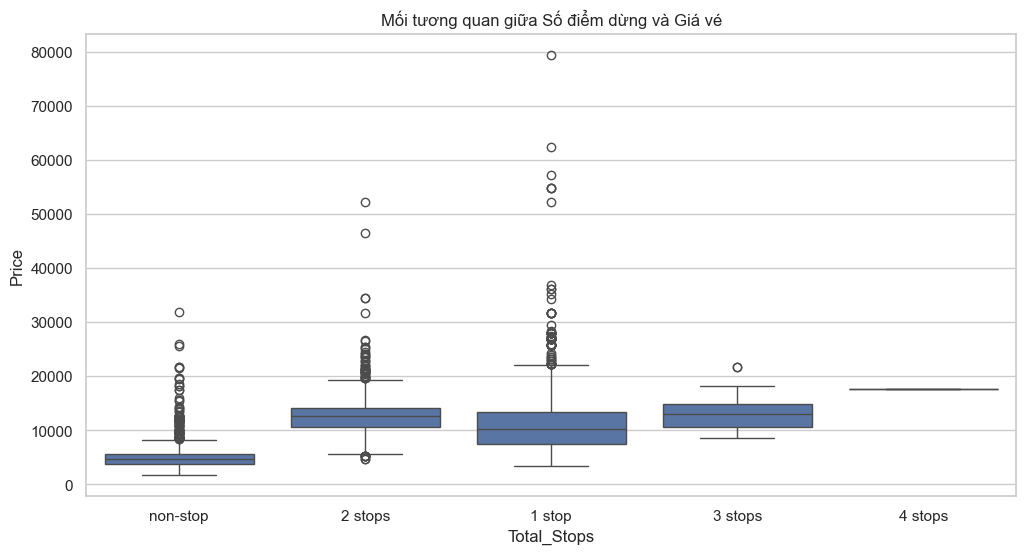

In [10]:
sns.boxplot(x='Total_Stops', y='Price', data=df)
plt.title('Mối tương quan giữa Số điểm dừng và Giá vé')
plt.show()

<!-- @format -->

### Biểu đồ Boxplot theo Điểm dừng tiết lộ quy luật vận hành:

- Có một sự tương quan thuận rõ rệt — số lượng điểm dừng càng nhiều thì giá vé trung bình càng có xu hướng cao hơn.

- Ta thấy 0 stops (Bay thẳng) có giá rẻ nhất và ổn định nhất.

- 1 stop và 2 stops có giá tăng mạnh và có rất nhiều giá trị ngoại lai.

- 4 stops có mức giá khá cao nhưng số lượng mẫu có vẻ ít.

- Từ đó ta có thể đoán được việc nối chuyến trong tập dữ liệu này không phải để tiết kiệm tiền cho khách hàng mà thường là do các chặng bay dài, phức tạp nên chi phí đội lên cao.
